# Chapter 139 — Basis and Dimension

> **Prerequisites:** ch138 (Subspaces), ch137 (Vector Spaces), ch127 (Linear Combination), ch135 (Orthogonality)  
> **You will learn:**
> - What a basis is and why it is the minimal complete description of a subspace
> - How to verify that a set of vectors forms a basis
> - Why all bases for the same space have the same number of vectors (dimension)
> - How to change coordinates between different bases
> - How dimension governs the complexity of a vector space
>
> **Environment:** Python 3.x, numpy, matplotlib

---

## 1. Concept

A **basis** for a vector space (or subspace) V is a set of vectors B = {**b₁**, **b₂**, ..., **bₙ**} that satisfies two conditions simultaneously:

1. **Span:** Every vector in V can be written as a linear combination of the vectors in B.
2. **Linear independence:** No vector in B can be written as a linear combination of the others — each vector contributes something new.

A basis is the *most efficient complete description* of a space. It is complete (you can reach every vector) and non-redundant (no element is superfluous).

The **dimension** of V, written dim(V), is the number of vectors in any basis of V. This is well-defined because all bases for the same space contain exactly the same number of vectors — a fact that is not obvious and requires proof.

**Common misconceptions:**
- "A basis is unique." Wrong — a space has infinitely many bases. The standard basis is just the most convenient one.
- "A larger set of vectors that spans V is a basis." Wrong — if vectors are redundant (linearly dependent), the set is not a basis.
- "Dimension is about how many directions you can point." Correct intuition, but only in the geometric sense — dimension is purely about the minimum number of vectors needed to span the space.

---

## 2. Intuition & Mental Models

**Geometric model:** Think of a basis as a minimal set of coordinate rulers. In ℝ² you need exactly two non-parallel rulers to locate any point: one for left-right, one for up-down. Any two linearly independent vectors in ℝ² form a valid basis — they define a coordinate system. Three vectors are redundant; one is insufficient.

**Computational model:** Think of a basis as a minimal complete codebook. Given any vector **v** in V, you can encode it as its coordinates (c₁, c₂, ..., cₙ) in the basis: **v** = c₁**b₁** + c₂**b₂** + ... + cₙ**bₙ**. The coordinates are unique — there is exactly one way to write any vector in terms of a basis. This uniqueness is what makes bases useful for computation.

Recall from ch127 (Linear Combination): a linear combination is any expression of the form c₁**v₁** + c₂**v₂** + ... A basis is a set of vectors such that every element of the space has *exactly one* such representation.

**Analogy:** A basis is like a coordinate system on a map. The map of France could be coordinatized with (latitude, longitude), or with (distance from Paris, angle from north). Both are valid coordinate systems — both have dimension 2. The two coordinates of any city differ between systems, but the city is the same. Dimension does not depend on which basis you pick.

---

## 3. Visualization

C:\Users\user\AppData\Local\Temp\ipykernel_20976\2886326792.py:79: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_20976\2886326792.py:79: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_20976\2886326792.py:79: UserWarning: Glyph 8477 (\N{DOUBLE-STRUCK CAPITAL R}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\user\OneDrive\Documents\book\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\user\OneDrive\Documents\book\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\user\OneDrive\Documents\book\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: 

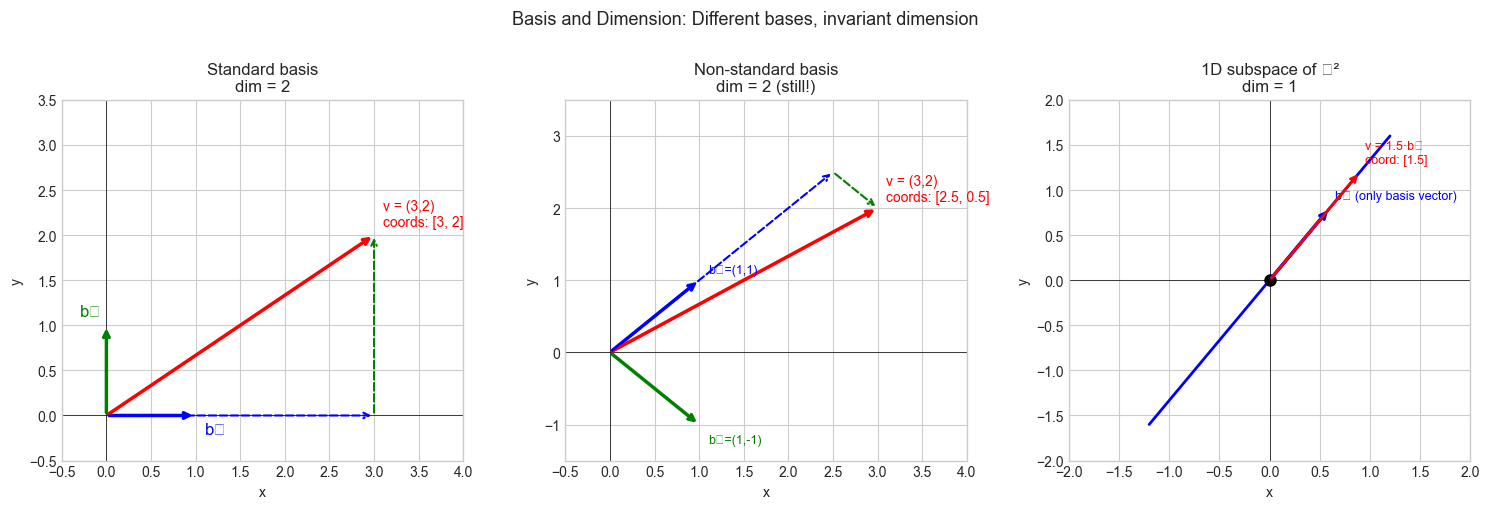

In [1]:
# --- Visualization: Two different bases for R^2, same dimension ---
# Shows that a vector has different coordinates in different bases,
# but dimension (= 2) is invariant.

import numpy as np
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Target vector
v = np.array([3.0, 2.0])

# --- Basis 1: Standard basis {e1, e2} ---
b1_1 = np.array([1.0, 0.0])
b1_2 = np.array([0.0, 1.0])
# Coordinates in standard basis: (3, 2) — trivially

ax = axes[0]
ax.annotate('', xy=b1_1, xytext=[0,0], arrowprops=dict(arrowstyle='->', color='blue', lw=2.5))
ax.annotate('', xy=b1_2, xytext=[0,0], arrowprops=dict(arrowstyle='->', color='green', lw=2.5))
ax.annotate('', xy=v, xytext=[0,0], arrowprops=dict(arrowstyle='->', color='red', lw=2.5))
# Show decomposition: 3*e1 + 2*e2
ax.annotate('', xy=3*b1_1, xytext=[0,0], arrowprops=dict(arrowstyle='->', color='blue', lw=1.5, linestyle='dashed'))
ax.annotate('', xy=v, xytext=3*b1_1, arrowprops=dict(arrowstyle='->', color='green', lw=1.5, linestyle='dashed'))
ax.text(1.1, -0.2, 'b₁', fontsize=12, color='blue')
ax.text(-0.3, 1.1, 'b₂', fontsize=12, color='green')
ax.text(v[0]+0.1, v[1]+0.1, f'v = (3,2)\ncoords: [3, 2]', fontsize=10, color='red')
ax.set_xlim(-0.5, 4); ax.set_ylim(-0.5, 3.5)
ax.set_title('Standard basis\ndim = 2')
ax.set_xlabel('x'); ax.set_ylabel('y')
ax.axhline(0, color='k', lw=0.5); ax.axvline(0, color='k', lw=0.5)

# --- Basis 2: Non-standard basis {(1,1), (1,-1)} ---
b2_1 = np.array([1.0, 1.0])
b2_2 = np.array([1.0, -1.0])
# Solve: c1*(1,1) + c2*(1,-1) = (3,2)
# c1 + c2 = 3, c1 - c2 = 2  => c1=2.5, c2=0.5
B2 = np.column_stack([b2_1, b2_2])
coords2 = np.linalg.solve(B2, v)

ax = axes[1]
ax.annotate('', xy=b2_1, xytext=[0,0], arrowprops=dict(arrowstyle='->', color='blue', lw=2.5))
ax.annotate('', xy=b2_2, xytext=[0,0], arrowprops=dict(arrowstyle='->', color='green', lw=2.5))
ax.annotate('', xy=v, xytext=[0,0], arrowprops=dict(arrowstyle='->', color='red', lw=2.5))
ax.annotate('', xy=coords2[0]*b2_1, xytext=[0,0],
             arrowprops=dict(arrowstyle='->', color='blue', lw=1.5, linestyle='dashed'))
ax.annotate('', xy=v, xytext=coords2[0]*b2_1,
             arrowprops=dict(arrowstyle='->', color='green', lw=1.5, linestyle='dashed'))
ax.text(b2_1[0]+0.1, b2_1[1]+0.1, 'b₁=(1,1)', fontsize=9, color='blue')
ax.text(b2_2[0]+0.1, b2_2[1]-0.25, 'b₂=(1,-1)', fontsize=9, color='green')
ax.text(v[0]+0.1, v[1]+0.1, f'v = (3,2)\ncoords: [{coords2[0]:.1f}, {coords2[1]:.1f}]', fontsize=10, color='red')
ax.set_xlim(-0.5, 4); ax.set_ylim(-1.5, 3.5)
ax.set_title('Non-standard basis\ndim = 2 (still!)')
ax.set_xlabel('x'); ax.set_ylabel('y')
ax.axhline(0, color='k', lw=0.5); ax.axvline(0, color='k', lw=0.5)

# --- Panel 3: 1D subspace in R^2 (a line) ---
ax = axes[2]
direction = np.array([0.6, 0.8])  # unit vector
t_vals = np.linspace(-2, 2, 200)
line_pts = np.outer(t_vals, direction)
ax.plot(line_pts[:, 0], line_pts[:, 1], 'b-', lw=2, label='1D subspace (a line)')
ax.annotate('', xy=direction, xytext=[0,0],
             arrowprops=dict(arrowstyle='->', color='blue', lw=2.5))
ax.text(direction[0]+0.05, direction[1]+0.1, 'b₁ (only basis vector)', fontsize=9, color='blue')
ax.plot(0, 0, 'ko', markersize=8)
# A vector in the subspace
v_sub = 1.5 * direction
ax.annotate('', xy=v_sub, xytext=[0,0], arrowprops=dict(arrowstyle='->', color='red', lw=2))
ax.text(v_sub[0]+0.05, v_sub[1]+0.1, f'v = 1.5·b₁\ncoord: [1.5]', fontsize=9, color='red')
ax.set_xlim(-2, 2); ax.set_ylim(-2, 2)
ax.set_title('1D subspace of ℝ²\ndim = 1')
ax.set_xlabel('x'); ax.set_ylabel('y')
ax.axhline(0, color='k', lw=0.5); ax.axvline(0, color='k', lw=0.5)

plt.suptitle('Basis and Dimension: Different bases, invariant dimension', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

---

## 4. Mathematical Formulation

**Definition — Basis:**  
A set B = {**b₁**, ..., **bₙ**} ⊂ V is a **basis** for V if:
```
(1) span(B) = V           (every v in V is reachable)
(2) B is linearly independent  (no redundancy)
```

Equivalently: every **v** ∈ V has a *unique* representation
```
v = c₁b₁ + c₂b₂ + ... + cₙbₙ
```
The scalars (c₁, ..., cₙ) are the **coordinates** of **v** in the basis B.

**Definition — Dimension:**  
The **dimension** of V, written dim(V), is the number of vectors in any basis of V.

**The key theorem (Invariance of Dimension):** Any two bases for the same finite-dimensional vector space have the same number of elements. This is non-trivial — it follows from the Steinitz exchange lemma — but the computational consequence is simple: rank(A) = dim(C(A)) regardless of which basis you use for the column space.

**Standard basis for ℝⁿ:**
```
e₁ = (1,0,0,...,0)
e₂ = (0,1,0,...,0)
...
eₙ = (0,0,...,0,1)
```
This is the canonical basis — the one that makes coordinates equal to components.

**Coordinate change formula:**  
Given bases B₁ and B₂ for V, the **change-of-basis matrix** P converts coordinates from B₁ to B₂:
```
[v]_B2 = P⁻¹ · [v]_B1
```
where P is the matrix whose columns are the B₁ basis vectors expressed in B₂ coordinates.

**Dimension facts:**
```
dim(ℝⁿ)              = n
dim({0})             = 0
dim(N(A))            = nullity(A) = n - rank(A)
dim(C(A))            = rank(A)
dim(W₁ + W₂)         = dim(W₁) + dim(W₂) - dim(W₁ ∩ W₂)  [inclusion-exclusion]
```
*(The null space result was introduced in ch138 — Subspaces)*

---

## 5. Python Implementation

In [2]:
# --- Implementation: Basis verification and coordinate extraction ---

import numpy as np


def is_basis(vectors, space_dim, tol=1e-10):
    """
    Check whether a list of vectors forms a basis for a space of given dimension.

    Args:
        vectors: list of np.ndarray, each shape (n,)
        space_dim: int — expected dimension of the space
        tol: float — numerical tolerance for rank check

    Returns:
        dict with keys: n_vectors, rank, is_basis, reason
    """
    B = np.column_stack(vectors)  # columns are the candidate basis vectors
    n_vectors = len(vectors)
    rank = np.linalg.matrix_rank(B, tol=tol)

    # A basis must have exactly space_dim linearly independent vectors
    if n_vectors != space_dim:
        reason = f"Wrong number of vectors: {n_vectors} given, need {space_dim}"
        ok = False
    elif rank < n_vectors:
        reason = f"Vectors are linearly dependent (rank={rank} < {n_vectors})"
        ok = False
    else:
        reason = "All conditions satisfied"
        ok = True

    return {'n_vectors': n_vectors, 'rank': rank, 'is_basis': ok, 'reason': reason}


def coordinates_in_basis(v, basis_vectors, tol=1e-9):
    """
    Find coordinates of v in the given basis.

    Solves: B @ c = v  where B has basis vectors as columns.

    Args:
        v: np.ndarray, shape (n,)
        basis_vectors: list of np.ndarray, each shape (n,)
        tol: float — residual tolerance for checking membership

    Returns:
        np.ndarray of coordinates, or raises ValueError if v not in span(basis)
    """
    B = np.column_stack(basis_vectors)
    # Least-squares solution
    c, residuals, rank, sv = np.linalg.lstsq(B, v, rcond=None)
    # Verify: reconstruction should match v
    residual = np.linalg.norm(B @ c - v)
    if residual > tol:
        raise ValueError(f"v is not in the span of the basis (residual={residual:.2e})")
    return c


# --- Test cases ---

print("=== Basis verification in R^3 ===")

# Standard basis — should be a basis for R^3
standard = [np.array([1.,0.,0.]), np.array([0.,1.,0.]), np.array([0.,0.,1.])]
print("Standard basis:", is_basis(standard, 3))

# Non-standard orthogonal basis
non_std = [
    np.array([1., 1., 0.]) / np.sqrt(2),
    np.array([1., -1., 0.]) / np.sqrt(2),
    np.array([0., 0., 1.])
]
print("Non-standard basis:", is_basis(non_std, 3))

# Linearly dependent — NOT a basis
dependent = [np.array([1.,2.,3.]), np.array([2.,4.,6.]), np.array([0.,1.,0.])]
print("Dependent vectors:", is_basis(dependent, 3))

# Too few vectors — NOT a basis for R^3
too_few = [np.array([1.,0.,0.]), np.array([0.,1.,0.])]
print("Too few vectors:", is_basis(too_few, 3))
print()

# --- Coordinate extraction ---
print("=== Coordinate extraction ===")
v = np.array([3., 2.])
basis_std = [np.array([1.,0.]), np.array([0.,1.])]
basis_alt = [np.array([1.,1.]), np.array([1.,-1.])]

c_std = coordinates_in_basis(v, basis_std)
c_alt = coordinates_in_basis(v, basis_alt)
print(f"v = {v}")
print(f"Coordinates in standard basis: {c_std}")
print(f"Coordinates in {{(1,1),(1,-1)}} basis: {c_alt}")

# Verify reconstruction
v_reconstructed = sum(c * b for c, b in zip(c_alt, basis_alt))
print(f"Reconstruction from alt coordinates: {v_reconstructed}  (should be {v})")

=== Basis verification in R^3 ===
Standard basis: {'n_vectors': 3, 'rank': np.int64(3), 'is_basis': True, 'reason': 'All conditions satisfied'}
Non-standard basis: {'n_vectors': 3, 'rank': np.int64(3), 'is_basis': True, 'reason': 'All conditions satisfied'}
Dependent vectors: {'n_vectors': 3, 'rank': np.int64(2), 'is_basis': False, 'reason': 'Vectors are linearly dependent (rank=2 < 3)'}
Too few vectors: {'n_vectors': 2, 'rank': np.int64(2), 'is_basis': False, 'reason': 'Wrong number of vectors: 2 given, need 3'}

=== Coordinate extraction ===
v = [3. 2.]
Coordinates in standard basis: [3. 2.]
Coordinates in {(1,1),(1,-1)} basis: [2.5 0.5]
Reconstruction from alt coordinates: [3. 2.]  (should be [3. 2.])


In [3]:
# --- Change of basis matrix ---

import numpy as np


def change_of_basis_matrix(basis_from, basis_to):
    """
    Compute the change-of-basis matrix P such that:
        [v]_to = P @ [v]_from

    Args:
        basis_from: list of np.ndarray — columns are basis vectors (source)
        basis_to:   list of np.ndarray — columns are basis vectors (target)

    Returns:
        np.ndarray, square matrix
    """
    B_from = np.column_stack(basis_from)  # matrix of source basis vectors
    B_to   = np.column_stack(basis_to)    # matrix of target basis vectors
    # [v]_to = B_to^{-1} @ B_from @ [v]_from
    return np.linalg.inv(B_to) @ B_from


# Example: change from standard basis to rotated basis
theta = np.pi / 4  # 45 degrees
basis_standard = [np.array([1.,0.]), np.array([0.,1.])]
basis_rotated  = [np.array([np.cos(theta), np.sin(theta)]),
                  np.array([-np.sin(theta), np.cos(theta)])]

P = change_of_basis_matrix(basis_standard, basis_rotated)
print("Change-of-basis matrix (standard -> rotated by 45°):")
print(P.round(4))

# Apply to a vector
v = np.array([1.0, 0.0])  # points in x-direction in standard basis
v_rotated_coords = P @ v
print(f"\nv = {v} in standard coords")
print(f"v = {v_rotated_coords.round(4)} in rotated coords")
print(f"(Should be [cos45, -sin45] = [{np.cos(theta):.4f}, {-np.sin(theta):.4f}])")

Change-of-basis matrix (standard -> rotated by 45°):
[[ 0.7071  0.7071]
 [-0.7071  0.7071]]

v = [1. 0.] in standard coords
v = [ 0.7071 -0.7071] in rotated coords
(Should be [cos45, -sin45] = [0.7071, -0.7071])


---

## 6. Experiments

In [4]:
# --- Experiment 1: How many bases does R^2 have? ---
# Hypothesis: Infinitely many — any two linearly independent vectors form a basis.
# We sample random pairs and check if they form valid bases.

import numpy as np

rng = np.random.default_rng(42)
N_TRIALS = 1000  # <-- modify this
RANGE = 3.0      # <-- try larger values; nearly-parallel vectors are more likely

valid_count = 0
det_values = []

for _ in range(N_TRIALS):
    v1 = rng.uniform(-RANGE, RANGE, size=2)
    v2 = rng.uniform(-RANGE, RANGE, size=2)
    B = np.column_stack([v1, v2])
    det = np.linalg.det(B)
    det_values.append(abs(det))
    if abs(det) > 1e-10:
        valid_count += 1

print(f"Out of {N_TRIALS} random pairs: {valid_count} form a valid basis")
print(f"({100*valid_count/N_TRIALS:.1f}% — almost all random pairs work)")
print(f"Mean |det|: {np.mean(det_values):.4f}")
print("\nConclusion: |det(B)| = 0 iff vectors are linearly dependent (measure zero event).")
print("The determinant is the key indicator — see ch158 (Determinants).")

Out of 1000 random pairs: 1000 form a valid basis
(100.0% — almost all random pairs work)
Mean |det|: 3.5498

Conclusion: |det(B)| = 0 iff vectors are linearly dependent (measure zero event).
The determinant is the key indicator — see ch158 (Determinants).


In [5]:
# --- Experiment 2: Dimension of subspaces defined by equations ---
# Hypothesis: Each linear equation reduces dimension by 1 (if independent).
# Try changing: the number of equations and their independence.

import numpy as np

# We're working in R^5
AMBIENT_DIM = 5  # <-- try 4, 6

# Each row defines an equation: a . x = 0
# These constraints define a subspace (intersection of hyperplanes through origin)

# Case 1: One independent constraint
A1 = np.array([[1, 2, 0, -1, 3]], dtype=float)

# Case 2: Two independent constraints
A2 = np.array([[1, 2, 0, -1, 3],
               [0, 1, -1, 2, 0]], dtype=float)

# Case 3: Two constraints, but second is multiple of first (dependent!)
A3 = np.array([[1, 2, 0, -1, 3],
               [2, 4, 0, -2, 6]], dtype=float)

for name, A in [("1 constraint", A1), ("2 independent", A2), ("2 dependent", A3)]:
    r = np.linalg.matrix_rank(A)
    dim_subspace = AMBIENT_DIM - r
    print(f"{name}: rank={r}, dim(null space) = {AMBIENT_DIM} - {r} = {dim_subspace}")

print()
print("Pattern: each independent equation removes one dimension.")
print(f"Starting from dim={AMBIENT_DIM}, k independent equations -> dim={AMBIENT_DIM}-k")

1 constraint: rank=1, dim(null space) = 5 - 1 = 4
2 independent: rank=2, dim(null space) = 5 - 2 = 3
2 dependent: rank=1, dim(null space) = 5 - 1 = 4

Pattern: each independent equation removes one dimension.
Starting from dim=5, k independent equations -> dim=5-k


In [6]:
# --- Experiment 3: Coordinates in different bases, same vector ---
# Hypothesis: Coordinates depend on basis; the vector itself does not.
# Reconstruct v from coordinates in 3 different bases and verify they all give v.

import numpy as np

v = np.array([1.0, 2.0, 3.0])  # <-- modify this vector

# Three different bases for R^3
bases = {
    'Standard': [np.eye(3)[:, i] for i in range(3)],
    'Scaled':   [np.array([2.,0.,0.]), np.array([0.,3.,0.]), np.array([0.,0.,5.])],
    'Rotated':  [
        np.array([1., 1., 0.]) / np.sqrt(2),
        np.array([-1., 1., 0.]) / np.sqrt(2),
        np.array([0., 0., 1.])
    ]
}

print(f"Target vector v = {v}")
print()

for name, basis in bases.items():
    B = np.column_stack(basis)
    coords = np.linalg.solve(B, v)
    reconstructed = B @ coords
    print(f"Basis '{name}':")
    print(f"  Coordinates:    {coords.round(4)}")
    print(f"  Reconstructed:  {reconstructed.round(10)}")
    print(f"  Matches v:      {np.allclose(reconstructed, v)}")
    print()

Target vector v = [1. 2. 3.]

Basis 'Standard':
  Coordinates:    [1. 2. 3.]
  Reconstructed:  [1. 2. 3.]
  Matches v:      True

Basis 'Scaled':
  Coordinates:    [0.5    0.6667 0.6   ]
  Reconstructed:  [1. 2. 3.]
  Matches v:      True

Basis 'Rotated':
  Coordinates:    [2.1213 0.7071 3.    ]
  Reconstructed:  [1. 2. 3.]
  Matches v:      True



---

## 7. Exercises

**Easy 1.** Which of the following sets is a basis for ℝ²?
- (a) {(1, 0), (0, 1)}
- (b) {(1, 2), (2, 4)}
- (c) {(1, 1), (1, -1)}
- (d) {(1, 0), (0, 1), (1, 1)}

*(Expected: a and c are bases; b has dependent vectors; d has too many)*

**Easy 2.** Write code to compute the dimension of the column space and null space of a random 4×6 matrix of rank 3. Verify that rank + nullity = 6.

**Medium 1.** Implement a function `extend_to_basis(vectors, n)` that takes a linearly independent set of vectors in ℝⁿ and extends it to a full basis by appending standard basis vectors as needed. *(Hint: add eᵢ vectors one at a time, checking if rank increases)*

**Medium 2.** The **dual basis** problem: given basis B = {**b₁**, **b₂**} for ℝ², find the dual basis B* = {**b₁***, **b₂***} such that **bᵢ*** · **bⱼ** = δᵢⱼ (Kronecker delta: 1 if i=j, else 0). This is the basis that makes the coordinate formula **c** = B*ᵀ**v** work directly. Implement this for ℝ².

**Hard.** Prove computationally that any set of n+1 vectors in an n-dimensional space must be linearly dependent. Write code that: (a) generates n+1 random vectors in ℝⁿ, (b) computes the rank of the matrix they form, (c) verifies the rank is at most n — for many random trials. Then give a 2-sentence mathematical argument for why this must always be true.

---

## 8. Mini Project

In [ ]:
# --- Mini Project: Coordinate System Transformer ---
#
# Problem: A robotics arm operates in a sensor coordinate system defined by
# two non-perpendicular axes (sensor basis). Control commands are given in
# the world coordinate system (standard basis). Build a tool that converts
# between coordinate systems and visualizes both.
#
# Real-world context: coordinate transformations appear everywhere in robotics,
# computer graphics, and scientific instrumentation.

import numpy as np
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')

# --- Sensor basis (non-orthogonal, as in a misaligned sensor) ---
# These are the sensor axes expressed in world (standard) coordinates
sensor_b1 = np.array([1.0, 0.3])   # sensor x-axis (slightly tilted)
sensor_b2 = np.array([0.2, 1.0])   # sensor y-axis (slightly off-perpendicular)
# <-- try making these orthogonal: [1,0] and [0,1]
# <-- try making them nearly parallel (ill-conditioned): [1,0.1] and [2,0.2]

SENSOR_BASIS = [sensor_b1, sensor_b2]
B_sensor = np.column_stack(SENSOR_BASIS)

print("Sensor basis matrix B:")
print(B_sensor)
print(f"det(B) = {np.linalg.det(B_sensor):.4f}  (non-zero means it's a valid basis)")

# --- TODO 1: Build world_to_sensor and sensor_to_world transforms ---
# world_to_sensor: given a point in world coords, find its sensor coords
# sensor_to_world: given sensor coords, find world coords
def world_to_sensor(v_world, B):
    """Convert world coordinates to sensor coordinates."""
    return np.linalg.solve(B, v_world)

def sensor_to_world(v_sensor, B):
    """Convert sensor coordinates to world coordinates."""
    return B @ v_sensor

# --- Test with some world points ---
world_points = np.array([
    [1.0, 0.0],
    [0.0, 1.0],
    [1.0, 1.0],
    [2.0, -1.0]
])

print("\nCoordinate conversion table:")
print(f"{'World coords':>20}  {'Sensor coords':>20}  {'Roundtrip error':>15}")
for wp in world_points:
    sc = world_to_sensor(wp, B_sensor)
    wp_back = sensor_to_world(sc, B_sensor)
    err = np.linalg.norm(wp - wp_back)
    print(f"  ({wp[0]:+.2f}, {wp[1]:+.2f})          "
          f"({sc[0]:+.4f}, {sc[1]:+.4f})          {err:.2e}")

# --- TODO 2: Visualize both coordinate grids ---
fig, ax = plt.subplots(figsize=(8, 8))

# World grid (standard)
for i in np.arange(-3, 4):
    ax.axhline(i, color='lightblue', lw=0.8, alpha=0.7)
    ax.axvline(i, color='lightblue', lw=0.8, alpha=0.7)

# Sensor grid (slanted)
t = np.linspace(-4, 4, 100)
for i in np.arange(-3, 4):
    # Lines parallel to sensor_b1
    line = np.outer(t, sensor_b1) + i * sensor_b2
    ax.plot(line[:, 0], line[:, 1], color='orange', lw=0.8, alpha=0.7)
    # Lines parallel to sensor_b2
    line = np.outer(t, sensor_b2) + i * sensor_b1
    ax.plot(line[:, 0], line[:, 1], color='orange', lw=0.8, alpha=0.7)

# Basis vectors
ax.annotate('', xy=sensor_b1, xytext=[0,0],
             arrowprops=dict(arrowstyle='->', color='darkorange', lw=3))
ax.annotate('', xy=sensor_b2, xytext=[0,0],
             arrowprops=dict(arrowstyle='->', color='darkorange', lw=3))
ax.text(sensor_b1[0]+0.05, sensor_b1[1]+0.05, 'b₁ (sensor)', color='darkorange', fontsize=11)
ax.text(sensor_b2[0]+0.05, sensor_b2[1]+0.05, 'b₂ (sensor)', color='darkorange', fontsize=11)

# World points and their sensor coordinates
for wp in world_points:
    sc = world_to_sensor(wp, B_sensor)
    ax.plot(*wp, 'bo', markersize=8, zorder=5)
    ax.text(wp[0]+0.05, wp[1]+0.08,
            f'W:({wp[0]:.0f},{wp[1]:.0f})\nS:({sc[0]:.2f},{sc[1]:.2f})',
            fontsize=8, color='blue')

ax.set_xlim(-2.5, 3.5)
ax.set_ylim(-2.5, 3.5)
ax.set_xlabel('World x')
ax.set_ylabel('World y')
ax.set_title('World grid (blue) vs Sensor grid (orange)\nPoints shown in both coordinate systems')
ax.axhline(0, color='gray', lw=1)
ax.axvline(0, color='gray', lw=1)
plt.tight_layout()
plt.show()

---

## 9. Chapter Summary & Connections

**What was covered:**
- A basis is a minimal spanning set — linearly independent vectors that cover the entire space.
- Every vector in a space has a unique coordinate representation in any given basis.
- Dimension is the number of vectors in any basis — an invariant of the space, not the basis.
- The change-of-basis matrix converts coordinates between representations.
- dim(null space) + rank = number of columns (Rank-Nullity, introduced in ch138).

**Backward connection:** This formalizes ch138 (Subspaces) *(introduced in ch138)*: every subspace has a basis, and the number of basis vectors is its dimension. The null space of a rank-r matrix has dimension n-r; its column space has dimension r.

**Forward connections:**
- In ch140 (Span), we define span formally and prove that every subspace is the span of its basis vectors.
- In ch141 (Linear Independence), the independence condition is examined in depth — including tests for independence and geometric meaning.
- This will reappear in ch183 (Eigenvalue Computation), where eigenvectors form a basis that makes a matrix diagonal — a change of basis that exposes the matrix's intrinsic structure.
- In ch186 (PCA), the principal components are a basis for the subspace of maximum variance — dimension reduction is literally choosing a lower-dimensional basis.

**Going deeper:** The notion of dimension extends beyond finite-dimensional spaces. The space of all continuous functions on [0,1] is infinite-dimensional — Fourier analysis constructs a (countably infinite) basis for it. See Chapter 6 of Axler's *Linear Algebra Done Right*.